<a href="https://colab.research.google.com/github/Edw12/omics_data_analysis/blob/main/Notebooks/Spectral%20Biclustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import os
from google.colab import userdata

# Remove the directory if it already exists to ensure a clean clone
if os.path.exists('omics_data_analysis'):
    !rm -rf omics_data_analysis

# Retrieve GitHub Token from Colab Secrets
GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')

# Clone the private repository using the PAT
!git clone https://{GITHUB_TOKEN}@github.com/Edw12/omics_data_analysis.git

Cloning into 'omics_data_analysis'...
remote: Enumerating objects: 82, done.
remote: Counting objects: 100% (82/82), done.
remote: Compressing objects: 100% (77/77), done.
remote: Total 82 (delta 35), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (82/82), 575.46 KiB | 9.13 MiB/s, done.
Resolving deltas: 100% (35/35), done.


In [2]:
import sys

In [4]:
import os
import sys
import importlib
import pandas as pd # Required for pd.ExcelFile in the modification logic

# --- Modify Random_Forest_Analysis.py for correct imports ---
rf_analysis_path = '/content/omics_data_analysis/Functions/SpectralBiclustering.py'
with open(rf_analysis_path, 'r') as f:
    rf_lines = f.readlines()

new_rf_lines = []
for line in rf_lines:
    if "from load_human_metabolites import load_human_metabolites" in line:
        new_rf_lines.append("from ..sup_func.load_human_metabolites import load_human_metabolites\n")
    elif "from Plot_Model_Results import Plot_Model_Results" in line:
        new_rf_lines.append("from ..sup_func.Plot_Model_Results import Plot_Model_Results\n")
    else:
        new_rf_lines.append(line)

with open(rf_analysis_path, 'w') as f:
    f.writelines(new_rf_lines)

print(f"Modified {rf_analysis_path} for correct imports.")

# --- Modify load_human_metabolites.py for correct file path and ensure imports ---
lm_path = '/content/omics_data_analysis/sup_func/load_human_metabolites.py'
with open(lm_path, 'r') as f:
    original_lm_lines = f.readlines()

desired_imports = ['import os\n', 'import pandas as pd\n']

# Filter out existing desired imports to avoid duplication, but keep other lines
filtered_lm_lines = []
for line in original_lm_lines:
    # Check if the line (stripped) is exactly one of the desired imports
    if line.strip() not in [imp.strip() for imp in desired_imports]:
        filtered_lm_lines.append(line)

new_lm_content = []
# Add desired imports at the very beginning of the file
new_lm_content.extend(desired_imports)

# Add the filtered original content, applying the path modification
for line in filtered_lm_lines:
    if 'file = pd.ExcelFile("human metabolites transposed.xlsx")' in line:
        # Construct the full path using os.path.join for robustness
        new_lm_content.append("    file_path = os.path.join(os.path.dirname(os.path.dirname(__file__)), 'Data', 'human metabolites transposed.xlsx')\n")
        new_lm_content.append("    file = pd.ExcelFile(file_path)\n")
    else:
        new_lm_content.append(line)

with open(lm_path, 'w') as f:
    f.writelines(new_lm_content)

print(f"Modified {lm_path} for correct data file path and ensured 'import os', 'import pandas'.")

# --- Reload modules after file modifications ---
# Before re-importing, remove the modules from sys.modules to force a fresh load
if 'omics_data_analysis.sup_func.load_human_metabolites' in sys.modules:
    del sys.modules['omics_data_analysis.sup_func.load_human_metabolites']
if 'omics_data_analysis.Functions.SpectralBiclustering' in sys.modules:
    del sys.modules['omics_data_analysis.Functions.SpectralBiclustering']

print("Modules removed from sys.modules cache for fresh reload.")

Modified /content/omics_data_analysis/Functions/SpectralBiclustering.py for correct imports.
Modified /content/omics_data_analysis/sup_func/load_human_metabolites.py for correct data file path and ensured 'import os', 'import pandas'.
Modules removed from sys.modules cache for fresh reload.


In [5]:
import sys

# Ensure the repository path is in sys.path
if '/content/omics_data_analysis' not in sys.path:
    sys.path.insert(0, '/content/omics_data_analysis')

# Import the specific functions from the freshly loaded modules
from omics_data_analysis.sup_func.Plot_Model_Results import Plot_Model_Results
from omics_data_analysis.sup_func.load_human_metabolites import load_human_metabolites
from omics_data_analysis.Functions.SpectralBiclustering import Spectral_Biclustering

In [7]:
clustering = Spectral_Biclustering(load_human_metabolites, data_frame = True)

In [8]:
clustering.perform_cluster(n_row_clusters = 4, n_col_clusters = 4)


ARI: 0.099, NMI: 0.144, AMI: 0.121
The p value is : 0.0


In [9]:
cluster_by_group, z_scores = clustering.cluster_groupings(output = True)

Cluster 0 (n=64): [0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 32, 39, 44, 55, 56, 57, 58, 68, 79, 80, 83, 87, 89, 91, 95, 101, 102, 103, 110, 116, 117, 160, 161, 162, 163, 164, 176, 177, 178, 179, 180, 182, 183, 184, 185, 189, 201, 204, 205, 206, 207, 209, 211, 212, 213, 214, 215, 216, 217, 219]
Cluster 1 (n=34): [7, 17, 22, 29, 30, 31, 34, 35, 42, 45, 67, 69, 71, 72, 73, 74, 75, 84, 85, 86, 90, 92, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 186, 192]
Cluster 2 (n=17): [25, 26, 27, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132]
Cluster 3 (n=105): [15, 16, 18, 19, 20, 21, 23, 24, 28, 33, 36, 37, 38, 40, 41, 43, 46, 47, 48, 49, 50, 51, 52, 53, 54, 59, 60, 61, 62, 63, 64, 65, 66, 70, 76, 77, 78, 81, 82, 88, 93, 94, 96, 97, 98, 99, 100, 104, 105, 106, 107, 108, 109, 111, 112, 113, 114, 115, 118, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 165, 181, 187, 188, 190, 191

In [10]:
clustering.show_purity_table()

col_0             0   1   2   3
row_0                          
Control_Female    7   6   4  11
Control_Male     19  24   3  10
Diabetic_Female   3   3  16   4
Diabetic_Male     8  11   3   0


In [11]:
row_col_relation = clustering.row_col_cluster_matrix()

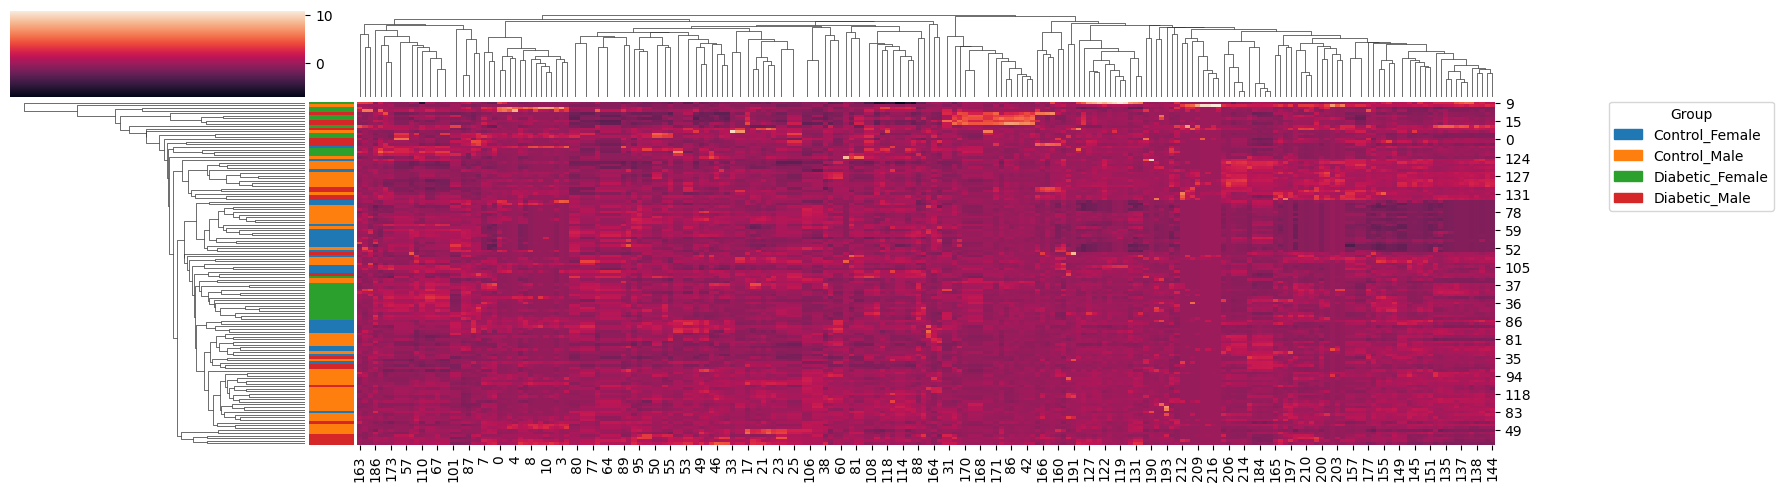

In [12]:
clustering.show_heatmap()

In [13]:
clustering.heatmap_groupings(n_clusters_visual = 6)

Cluster 1 (n=24): [3, 76, 94, 50, 51, 52, 70, 48, 33, 36]...
Cluster 2 (n=17): [163, 162, 183, 186, 175, 172, 173, 58, 56, 57]...
Cluster 3 (n=72): [72, 101, 102, 83, 87, 44, 7, 15, 16, 0]...
Cluster 4 (n=18): [39, 1, 4, 12, 9, 5, 80, 77, 25, 26]...
Cluster 5 (n=6): [46, 22, 213, 211, 217, 184]...
Cluster 6 (n=83): [115, 170, 167, 168, 34, 35, 171, 85, 86, 84]...


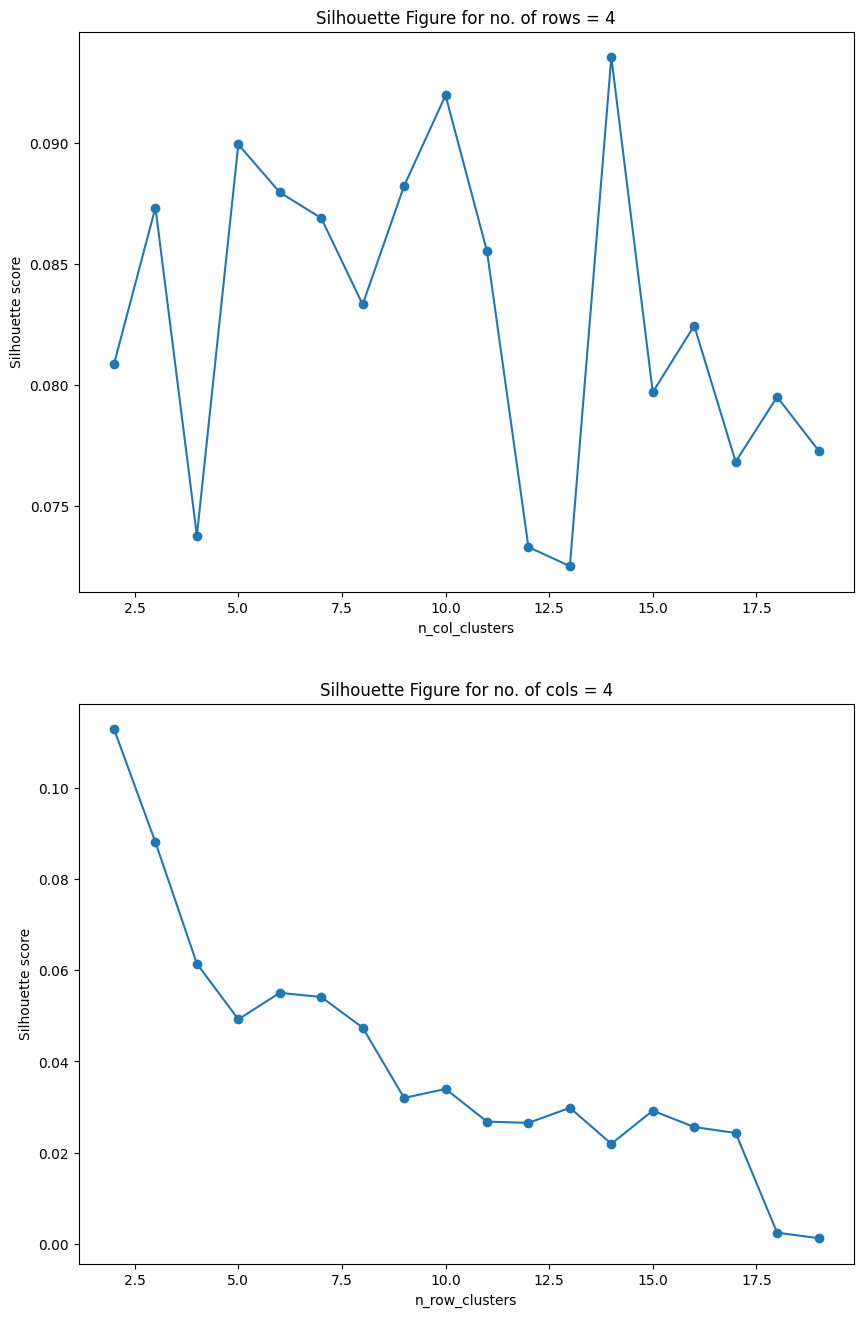

In [14]:
clustering.compare_silhouettes()

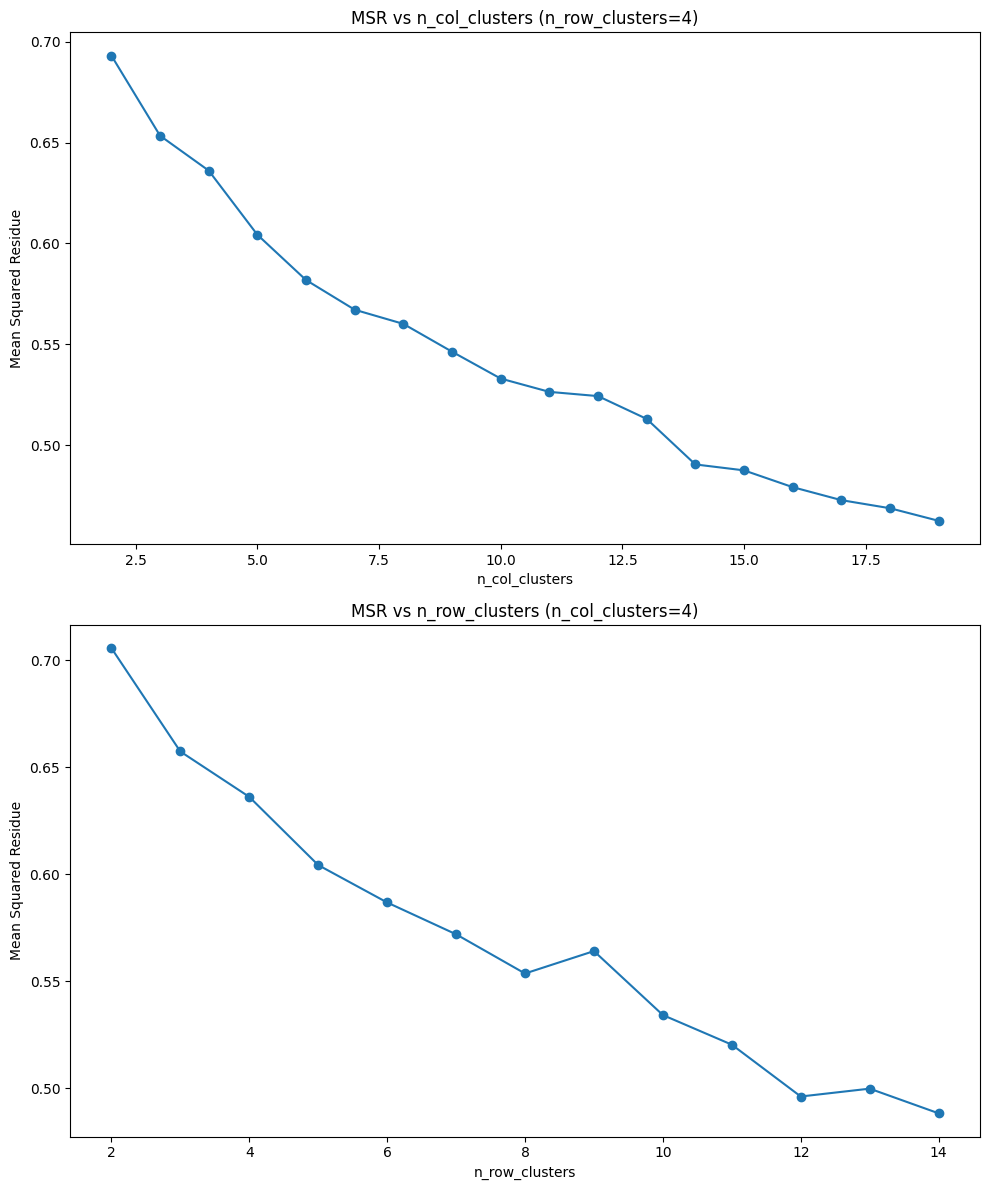

In [15]:
clustering.compare_msr()

In [16]:
clustering.stats_tests(group_a = "Diabetic_Female", group_b = "Diabetic_Male")

The significant results were: Empty DataFrame
Columns: [metabolite, p_value, fold_change, q_value]
Index: []
             mean_intensity_purple  mean_intensity_rest
col_cluster                                            
0                              NaN         2.518388e-17
1                              NaN        -9.534041e-17
2                              NaN         1.601728e-16
3                              NaN         4.935007e-17
